Import Model Configuration
==========================

In [1]:
import yaml

model_cfg = "maskrcnn_resnet50_fpn.yaml"

with open("./configs/" + model_cfg , "r") as f:
    cfg = yaml.safe_load(f)

cfg['experiment_name']

'maskrcnn_resnet50_fpn'

Dataset Class
=============

In [2]:
import os
import torch
from torch.utils.data import Dataset
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import numpy as np


class COCOSegmentationDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms

        # path to the JSON annotation file
        self.ann_path = os.path.join(root_dir, "_annotations.coco.json")
        self.coco = COCO(self.ann_path)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root_dir, img_info['file_name'])

        img = read_image(img_path)  # shape: [C, H, W]
        img = tv_tensors.Image(img)
        h, w = img.shape[-2:]

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        masks = []
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            if 'segmentation' not in ann:
                continue

            rles = coco_mask.frPyObjects(ann['segmentation'], h, w)
            mask = coco_mask.decode(rles)
            if mask.ndim == 3:
                mask = mask.any(axis=2)
            mask = torch.as_tensor(mask, dtype=torch.uint8)
            masks.append(mask)

            x, y, bw, bh = ann['bbox']
            boxes.append(torch.tensor([x, y, x + bw, y + bh], dtype=torch.float32))
            labels.append(ann.get('category_id', 1))
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        if masks:
            masks = torch.stack(masks)
            boxes = torch.stack(boxes)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)
        else:
            masks = torch.zeros((0, h, w), dtype=torch.uint8)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(h, w)),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": img_id,
            "area": areas,
            "iscrowd": iscrowd
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

            # ⚠️ Filter out zero-area boxes *after transforms*
            boxes = target["boxes"]
            keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])

            # Apply keep mask to all fields
            target["boxes"] = tv_tensors.BoundingBoxes(boxes[keep], format="XYXY", canvas_size=img.shape[-2:])
            target["labels"] = target["labels"][keep]
            if "masks" in target:
                target["masks"] = target["masks"][keep]
            if "area" in target:
                target["area"] = target["area"][keep]
            if "iscrowd" in target:
                target["iscrowd"] = target["iscrowd"][keep]

        return img, target

    def __len__(self):
        return len(self.ids)


Augmentiations
=============

In [3]:
from torchvision.transforms import v2 as T
import torch

def get_transform(train: bool):
    if train:
        transforms = [
            T.RandomPhotometricDistort(),  # Color jitter
            T.Resize((512, 512)),          # Fixed resize for stability
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10, fill=0, expand=False),  # Limit rotation area
            # T.RandomZoomOut(fill=0, p=0.3),  # Optional — leave off for now
            # T.RandomCrop((512, 512), pad_if_needed=False, fill=0),  # Only if images are bigger
        ]
        '''
        transforms = [
            T.RandomPhotometricDistort(),                           # Color jitter (safe for segmentation)
            T.RandomChoice([
                T.Resize(400),
                T.Resize(512),
                T.Resize(640),
            ]),                                                     # Random scale resize
            T.RandomCrop((512, 512), pad_if_needed=True, fill=0),   # Crop with padding
            T.RandomHorizontalFlip(p=0.5),                          # Horizontal flip
            T.RandomZoomOut(fill=0, p=0.5),                         # Random zoom out with black pad
            T.RandomRotation(degrees=10, fill=0),                   # Random rotation ±10 degrees with black fill
        ]
        '''
    else:
        transforms = [
            T.Resize((512, 512)),                                   # Consistent resize for val/test
        ]

    transforms += [
        T.ToDtype(torch.float32, scale=True),                       # Convert image to float32 in [0, 1]
        T.ToPureTensor(),                                           # Convert to torch.Tensor (Image, Mask, BBoxes)
    ]

    return T.Compose(transforms)

Initialization
=============

In [4]:
import utils  # Your helper functions (make sure it includes `collate_fn` from PyTorch references)
import torch
from torchvision.transforms import v2 as T
from engine import train_one_epoch, evaluate

from tqdm import tqdm
import sys
import time

from models import MODEL_REGISTRY



device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# COCO-style dataset using your structure
dataset = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/train",
    transforms=get_transform(train=True)
)

dataset_valid = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/valid",
    transforms=get_transform(train=False)
)

dataset_test = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/test",
    transforms=get_transform(train=False)
)


print("Train size:", len(dataset))
print("Validation size:", len(dataset_valid))
print("Test size:", len(dataset_test))

# Dynamically assign number of workers
n_workers = 4 if torch.cuda.is_available() else 0

# Dataloaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=cfg["train"]["batch_size"],
    shuffle=True,
    num_workers = n_workers,
    collate_fn=utils.collate_fn
)

data_loader_valid = torch.utils.data.DataLoader(
    dataset_valid,
    batch_size=1,
    shuffle=False,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

# Two classes: background + foreground
num_classes = cfg['num_classes']

# Load model
model = MODEL_REGISTRY[cfg["model"]](num_classes=cfg["num_classes"])
#model = get_model_instance_segmentation(num_classes)

model.to(device)

loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Train size: 1049
Validation size: 300
Test size: 150


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

Load Model
====================

In [5]:
# Load weights with correct device mapping
model.load_state_dict(torch.load(
    "outputs/maskrcnn_resnet50_fpn_20250609_1525/model_best.pth",
    map_location=device  # Automatically maps to CPU or CUDA as available
))

# Move model to device
model.to(device)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

Test (Example)
=====

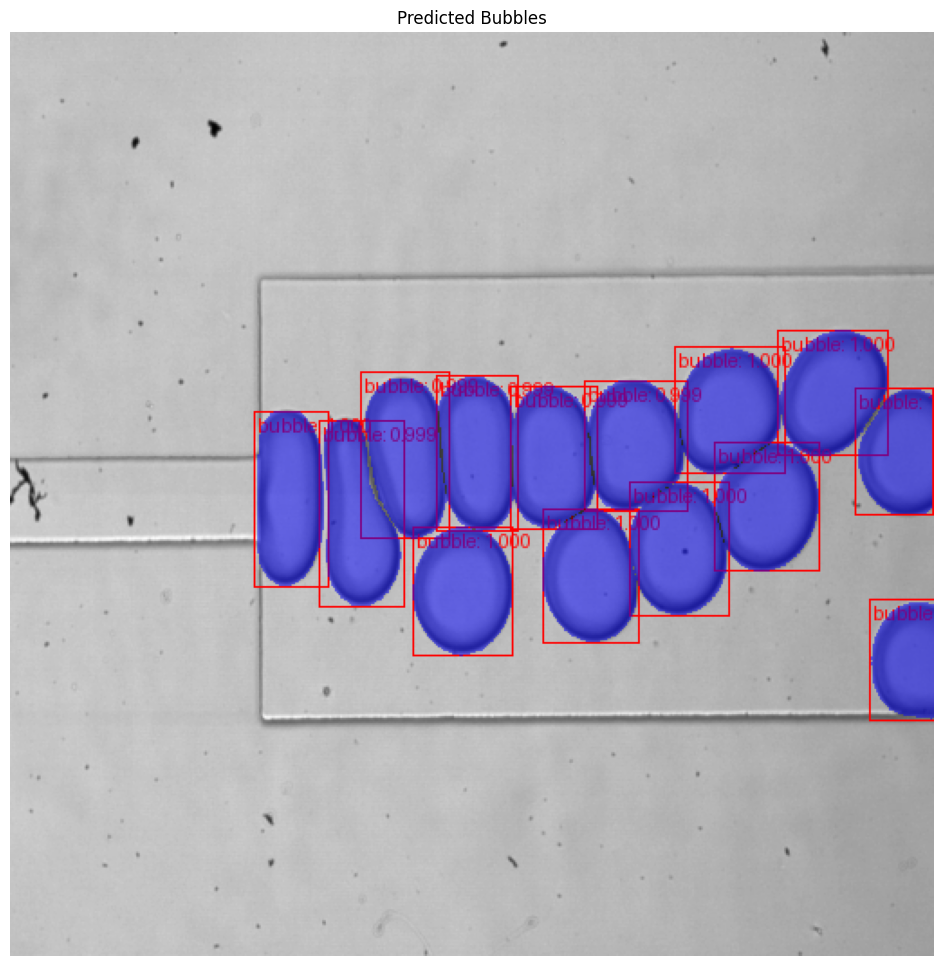

In [6]:
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torch

#image = read_image("../../../BubANN_GAN.v1i.coco-segmentation/test/BubGAN_0002_jpg.rf.a78f79c439aaf0c4cfcaac4ce751a071.jpg")
#image = read_image("../../../frames_ana\\02_07_20\\qc2_qd1_10x_formacao\\qc2_qd1_10x_formacao_00000.jpg")
image = read_image("../../../frames_ana\\02_07_20\\qc2_qd1_10x_formacao2\\qc2_qd1_10x_formacao2_00000.jpg")
eval_transform = get_transform(train=False)

score_thresh = 0.9  # Confidence threshold
min_area = 500     # Minimum bubble size in pixels

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    x = x[:3, ...].to(device)

    predictions = model([x])
    pred = predictions[0]

# Filter predictions by score
keep = pred["scores"] > score_thresh
scores = pred["scores"][keep]
boxes = pred["boxes"][keep]
masks = pred["masks"][keep]

# Filter masks by area (size)
areas = masks.sum(dim=[1, 2, 3])  # Sum over HxW for each mask
keep_area = areas > min_area

# Final filtered outputs
boxes = boxes[keep_area].cpu().long()
masks = (masks[keep_area].cpu() > 0.7).squeeze(1)
labels = [f"bubble: {score:.3f}" for score in scores[keep_area]]

# Prepare image for visualization (use x)
vis_img = (255.0 * (x.cpu() - x.cpu().min()) / (x.cpu().max() - x.cpu().min())).to(torch.uint8)
vis_img = vis_img[:3, ...]

#pred_labels = [f"bubble: {score:.3f}" for score in pred["scores"]]
#pred_boxes = pred["boxes"].cpu().long()
#masks = (pred["masks"].cpu() > 0.7).squeeze(1)

output_image = draw_bounding_boxes(vis_img, boxes, labels, colors="red")
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))
plt.axis("off")
plt.title("Predicted Bubbles")
plt.show()

Test Batch
=========

Starting...
model eval finished...
torch no grad...
Image 0
Precision: 0.9767800366123904
Recall: 0.9798956118306592
F1: 0.978335343787696
Intersection: 10138
Union: 10587
Dice: 0.9783353437404905
Drawing predictions...


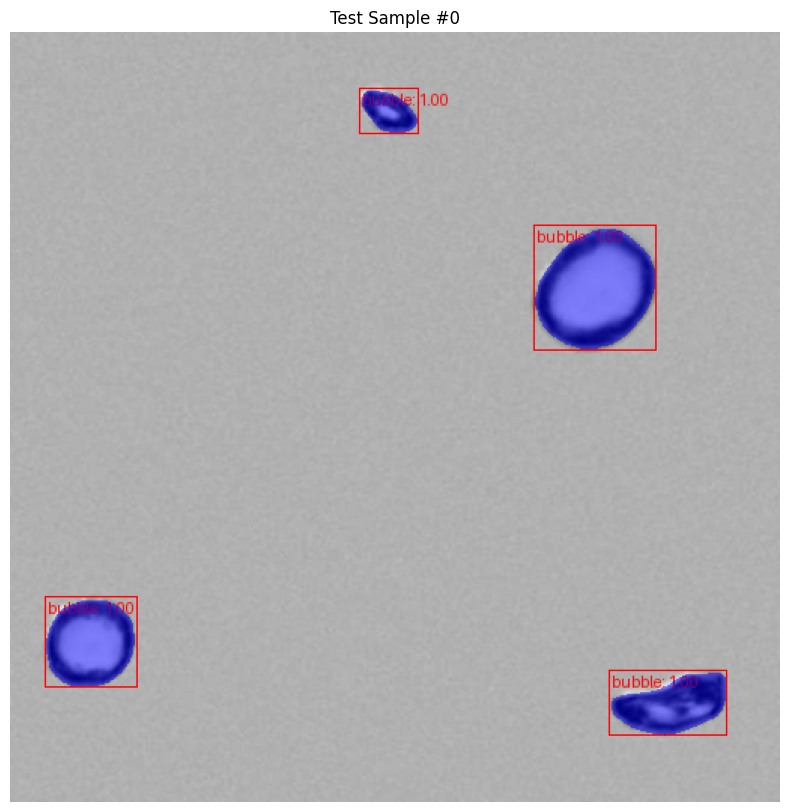

Image 1
Precision: 0.9978498827208757
Recall: 0.915695067264574
F1: 0.9550088859788607
Intersection: 20420
Union: 22344
Dice: 0.9550088859565287
Drawing predictions...


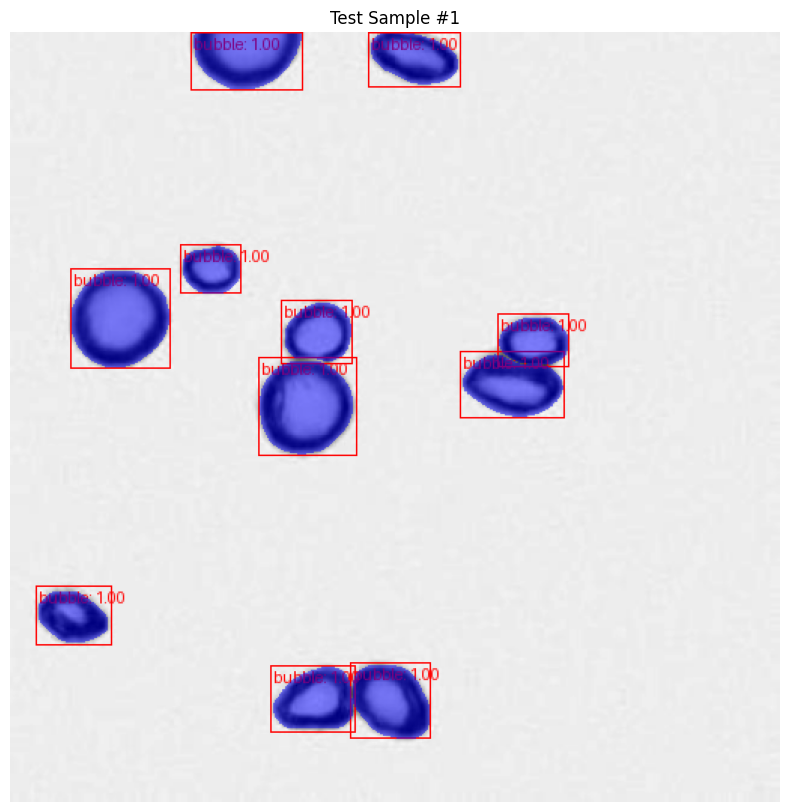

Image 2
Precision: 1.0
Recall: 0.8900624977157268
F1: 0.9418339327841591
Intersection: 24353
Union: 27361
Dice: 0.9418339327659466
Drawing predictions...


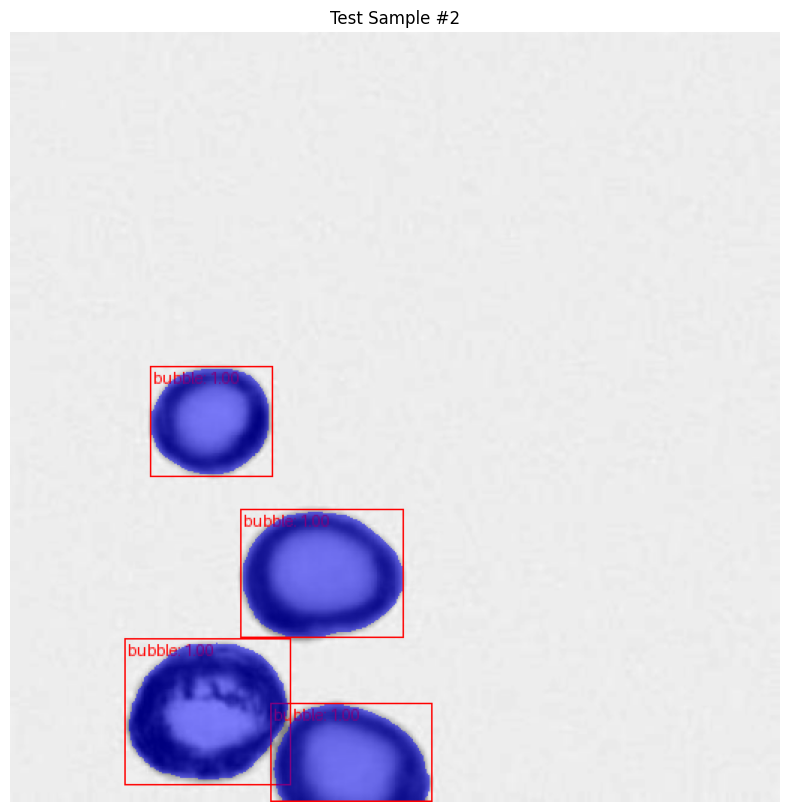

Image 3
Precision: 0.9468280506758348
Recall: 0.9920063159972368
F1: 0.9688908166461843
Intersection: 20104
Union: 21395
Dice: 0.9688908166228369
Drawing predictions...


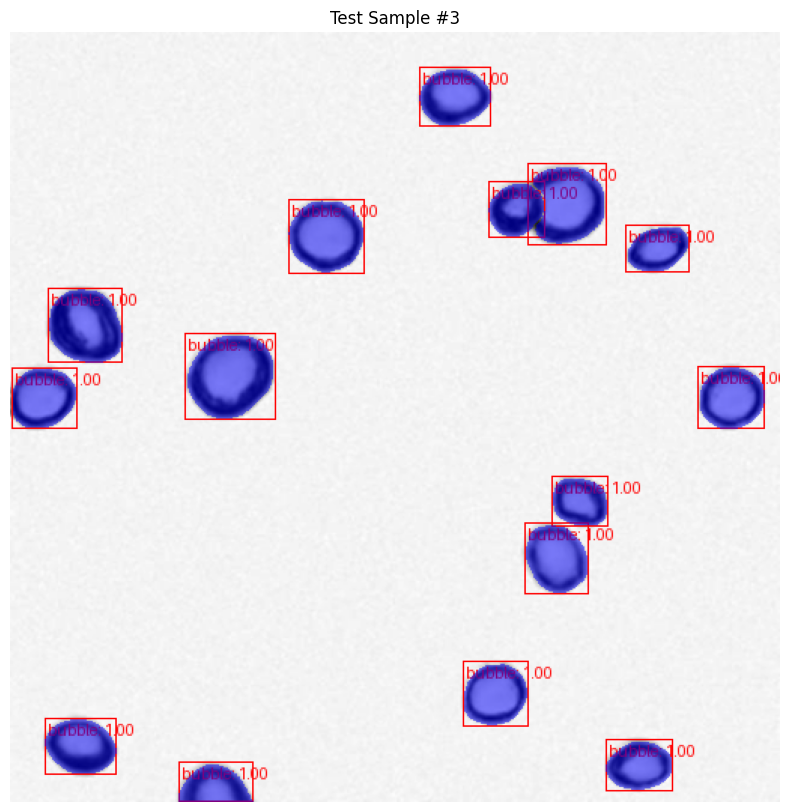

Image 4
Precision: 0.963407973784817
Recall: 0.9673704414587332
F1: 0.9653851416062389
Intersection: 14112
Union: 15124
Dice: 0.9653851415732184
Drawing predictions...


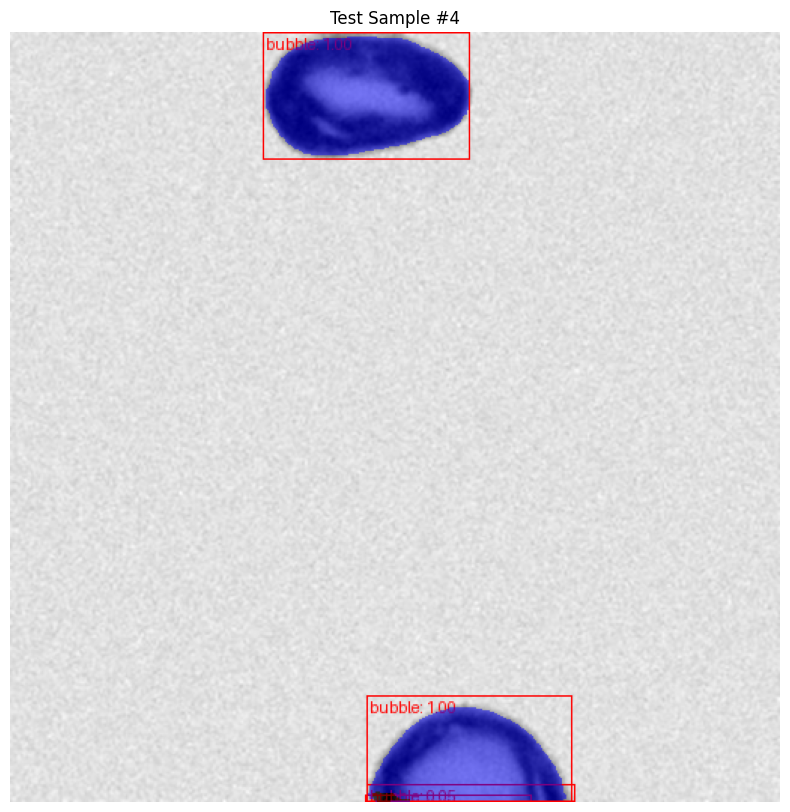

Image 5
Precision: 0.9821413634462568
Recall: 0.9927707787266424
F1: 0.9874274661508704
Intersection: 23483
Union: 24081
Dice: 0.9874274661301105
Drawing predictions...


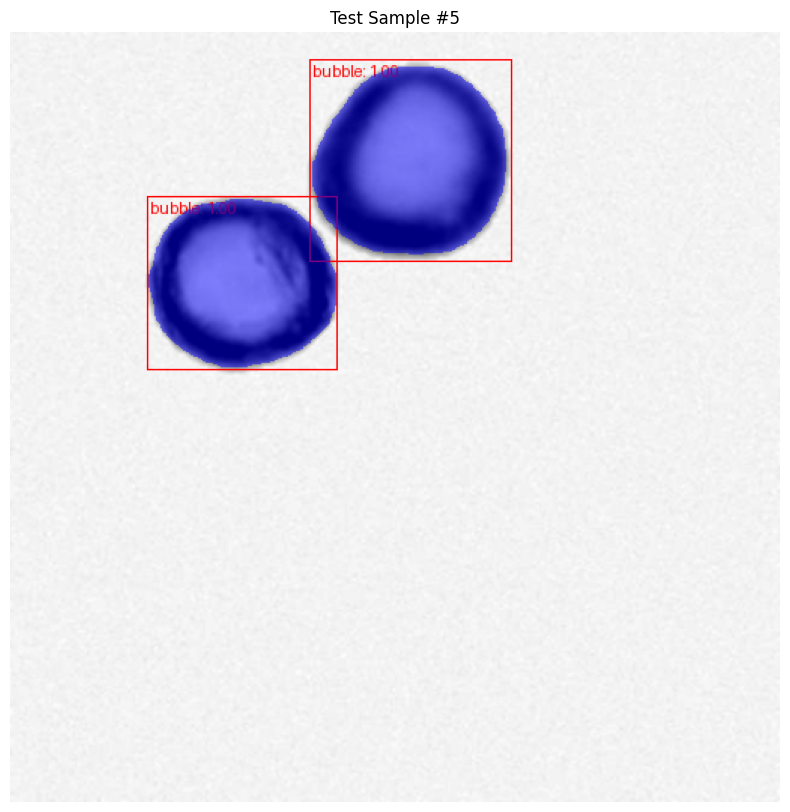

Image 6
Precision: 0.9994389054339851
Recall: 0.8701991732431417
F1: 0.9303521565318709
Intersection: 23156
Union: 26623
Dice: 0.9303521565131813
Drawing predictions...


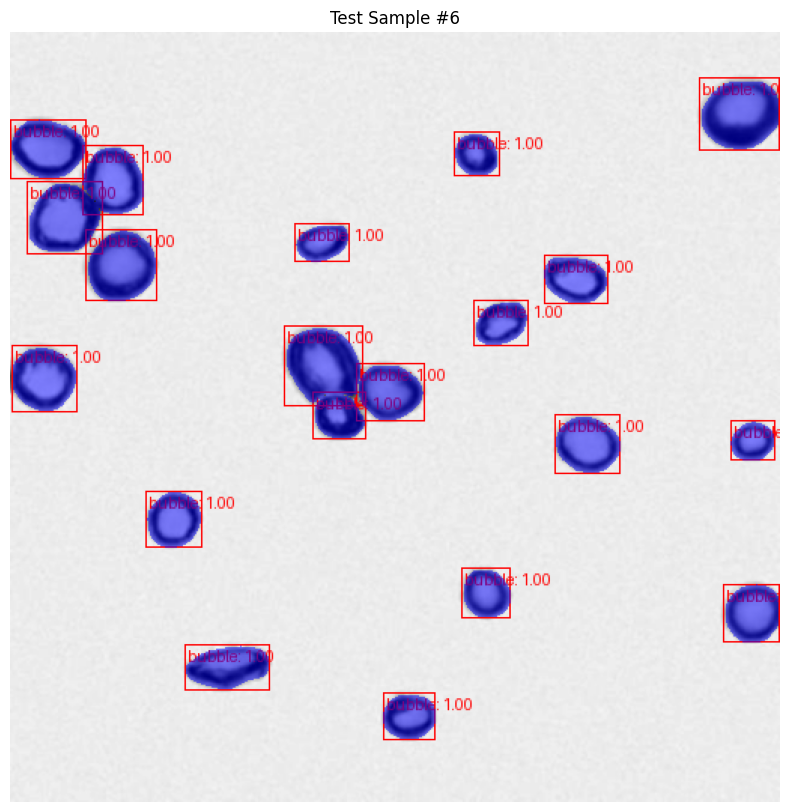

Image 7
Precision: 0.9968412740194789
Recall: 0.9044230034390524
F1: 0.9483859657909894
Intersection: 18935
Union: 20996
Dice: 0.9483859657672389
Drawing predictions...


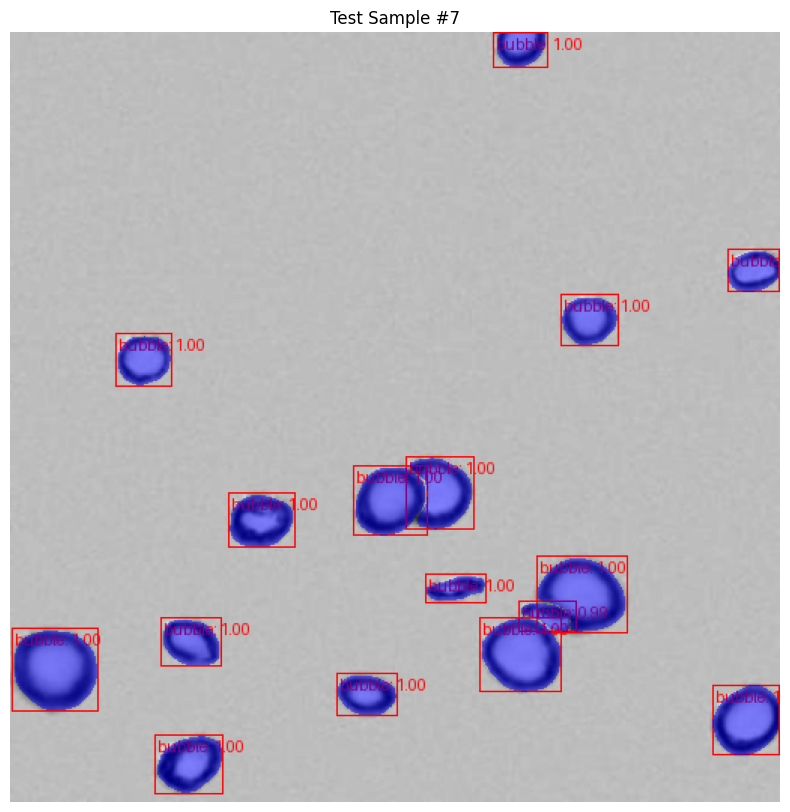

Image 8
Precision: 0.9800679923625017
Recall: 0.9849761303004774
F1: 0.9825159317444385
Intersection: 21045
Union: 21794
Dice: 0.9825159317215034
Drawing predictions...


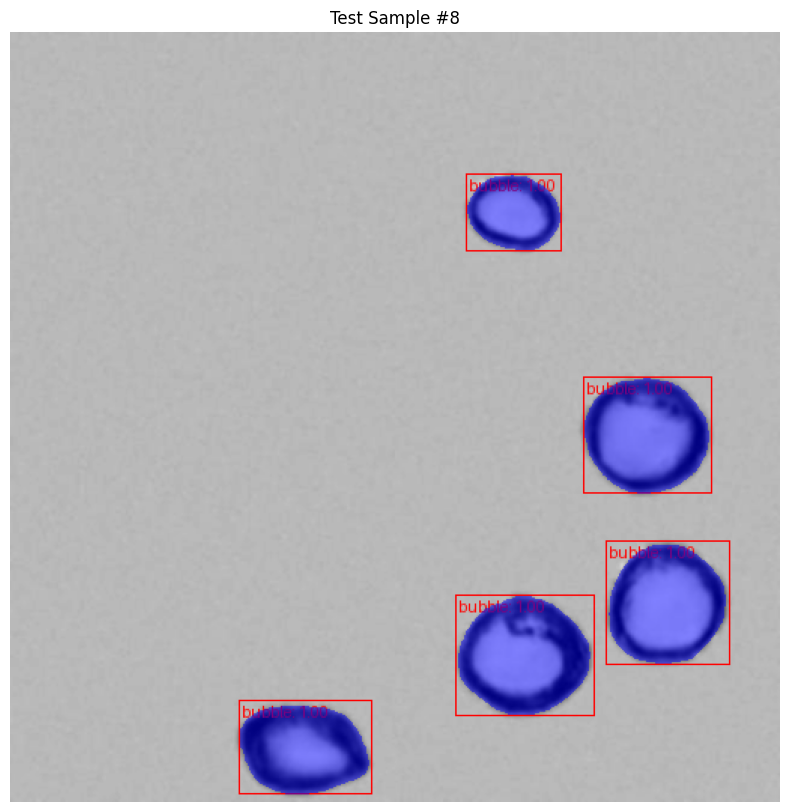

Image 9
Precision: 0.9687485247604211
Recall: 0.9744527280497649
F1: 0.9715922541546328
Intersection: 20521
Union: 21721
Dice: 0.9715922541316322
Drawing predictions...


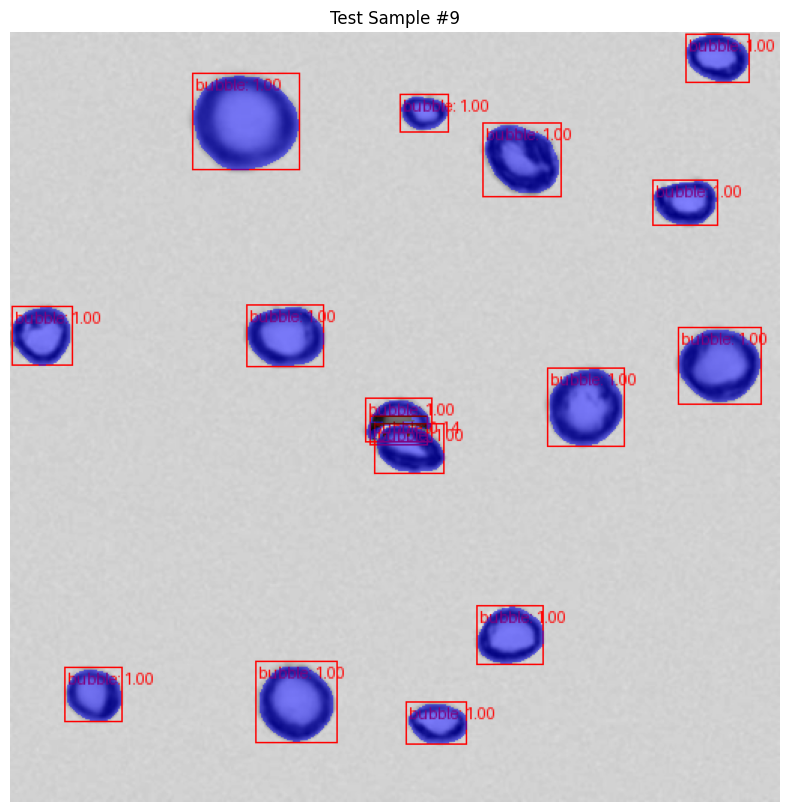

Average Precision: 0.9812104003816563
Average Recall: 0.947185174802601
Average F1-score: 0.9629727895175941
Average Dice Coefficient: 0.9629727894922688


In [7]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.functional as F
import torch

from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

print(f"Starting...")

model.eval()

print(f"model eval finished...")

# Number of test images to visualize
N = 10

with torch.no_grad():

    print(f"torch no grad...")

    dice_scores = []
    precisions = []
    recalls = []
    f1_scores = []

    for idx, (image, target) in enumerate(data_loader_test):

        if idx >= N:
            break

        print(f"Image {idx}")

        x = image[0].to(device)  # batch size = 1
        x = x[:3, ...]  # Remove alpha channel if present

        pred = model([x])[0]

        pred_masks = (pred["masks"].cpu() > 0.7).squeeze(1).numpy()
        true_masks = target[0]["masks"].cpu().numpy()

        # Combine all masks into one binary mask (union of all instances)
        pred_mask = np.any(pred_masks, axis=0).astype(np.uint8)
        true_mask = np.any(true_masks, axis=0).astype(np.uint8)

        # Flatten for sklearn metrics
        pred_flat = pred_mask.flatten()
        true_flat = true_mask.flatten()

        # Skip empty ground truth
        if true_flat.sum() == 0:
            continue

        precision = precision_score(true_flat, pred_flat, zero_division=0)
        recall = recall_score(true_flat, pred_flat, zero_division=0)
        f1 = f1_score(true_flat, pred_flat, zero_division=0)
        intersection = np.logical_and(pred_mask, true_mask).sum()
        union = np.logical_or(pred_mask, true_mask).sum()
        dice = (2 * intersection) / (pred_mask.sum() + true_mask.sum() + 1e-6)

        print(f"Precision: {precision}")
        print(f"Recall: {recall}")
        print(f"F1: {f1}")
        print(f"Intersection: {intersection}")
        print(f"Union: {union}")
        print(f"Dice: {dice}")

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        dice_scores.append(dice)


        
        # Rescale image for visualization
        x_cpu = x.cpu()
        vis_img = (255.0 * (x_cpu - x_cpu.min()) / (x_cpu.max() - x_cpu.min())).to(torch.uint8)

        pred_labels = [f"bubble: {score:.2f}" for score in pred["scores"]]
        pred_boxes = pred["boxes"].cpu().long()
        masks = (pred["masks"].cpu() > 0.7).squeeze(1)

        print(f"Drawing predictions...")

        output_image = draw_bounding_boxes(vis_img, pred_boxes, pred_labels, colors="red")
        output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

        # Plot
        plt.figure(figsize=(10, 10))
        plt.imshow(output_image.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"Test Sample #{idx}")
        plt.show()
        
        
    
    print("Average Precision:", np.mean(precisions))
    print("Average Recall:", np.mean(recalls))
    print("Average F1-score:", np.mean(f1_scores))
    print("Average Dice Coefficient:", np.mean(dice_scores))




Final Evaluation Metrics:
Average Precision:         0.9890
Average Recall:            0.9429
Average F1-score:          0.9650
Average Dice Coefficient:  0.9650
Average IoU (Jaccard):     0.9327


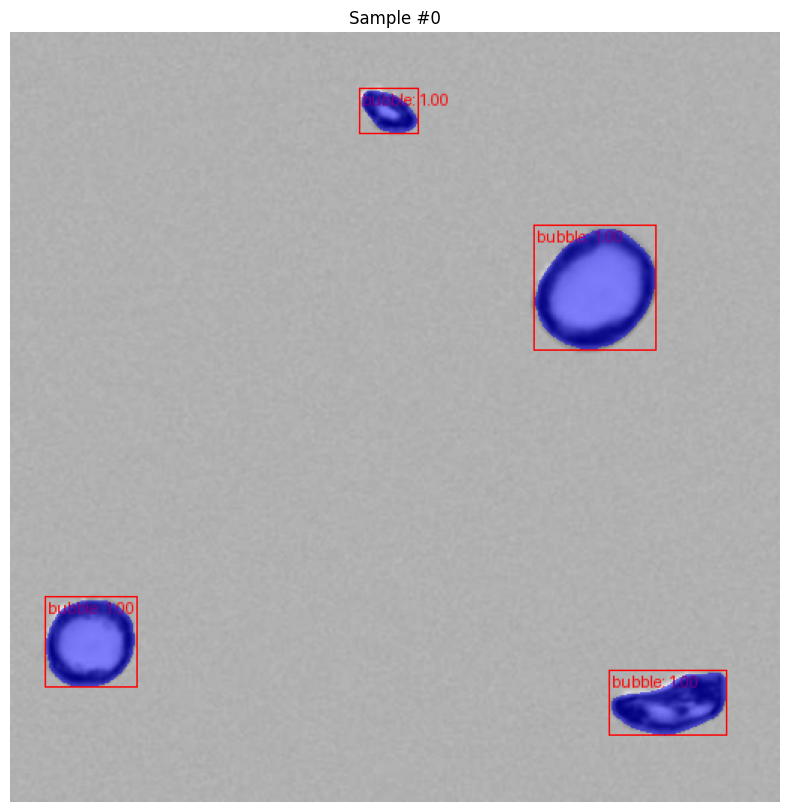

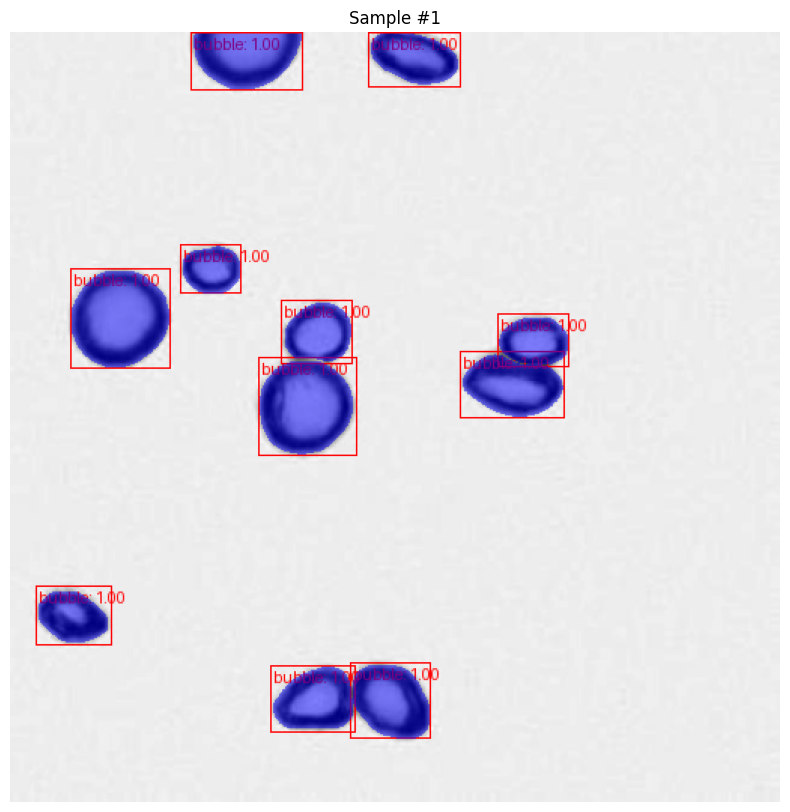

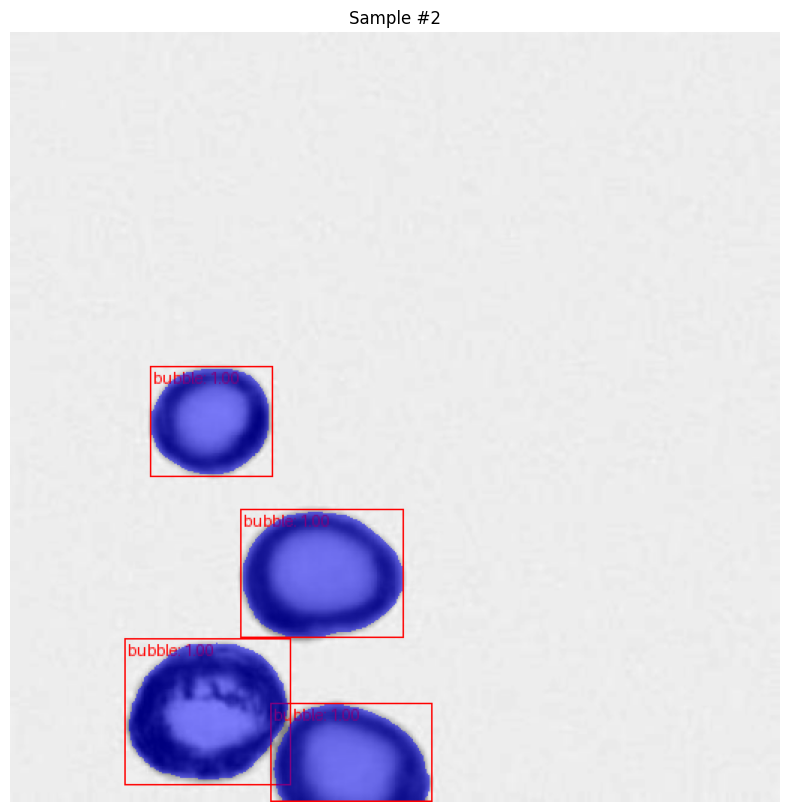

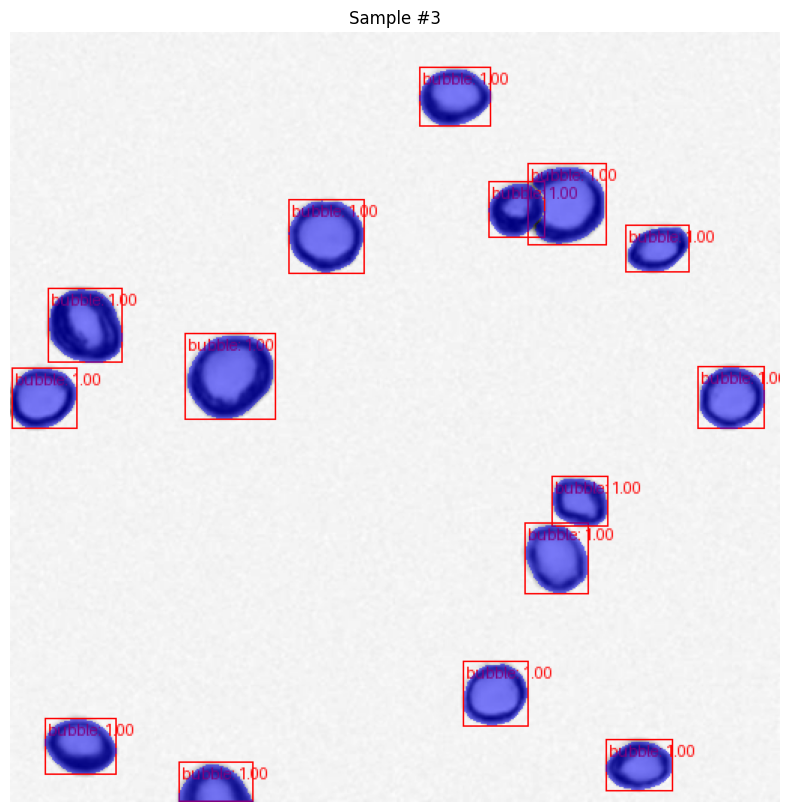

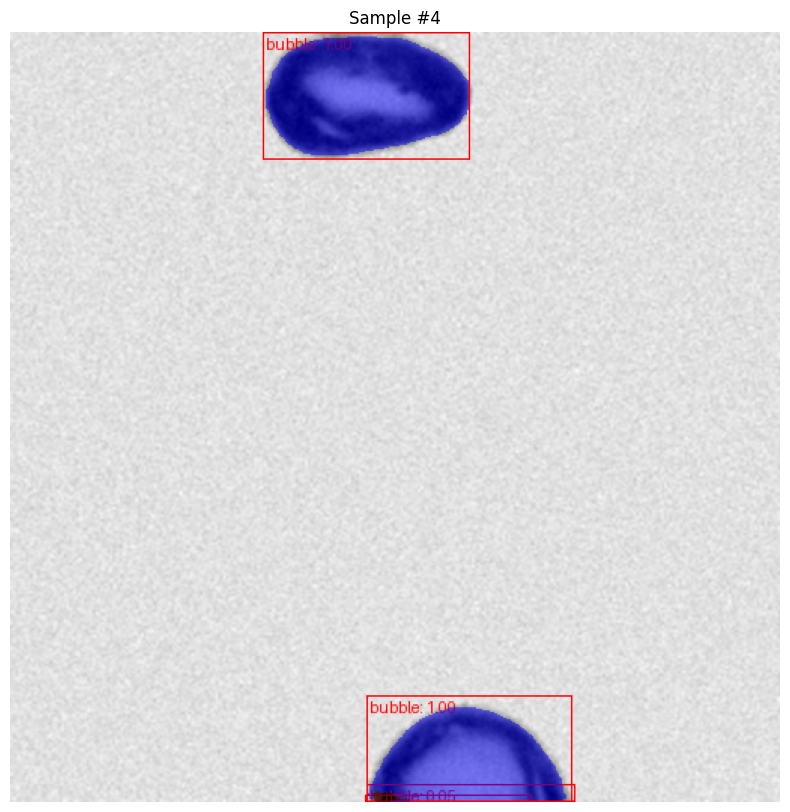


Final Evaluation Metrics:
Average Precision:         0.9770
Average Recall:            0.9490
Average F1-score:          0.9619
Average Dice Coefficient:  0.9619
Average IoU (Jaccard):     0.9269


In [8]:
from results_eval import evaluate_segmentation_metrics

# Evaluate on all 150 test images, no visualization
evaluate_segmentation_metrics(model, data_loader_test, device=device)

# For debug/visualization on first 5 test images
evaluate_segmentation_metrics(model, data_loader_test, device=device, max_images=5, visualize=True)
